In [4]:
# Task 2: Technical Analysis - Clean version
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import ta
import warnings
warnings.filterwarnings('ignore')

print("✅ All packages imported successfully!")
print(f"✅ TA-Lib version: {ta.__version__}")

✅ All packages imported successfully!


AttributeError: module 'ta' has no attribute '__version__'

In [8]:
# Define stocks to analyze - CORRECTED VERSION
top_stocks = ['AAPL', 'GOOGL', 'MSFT', 'AMZN', 'TSLA', 'META', 'NVDA', 'JPM', 'JNJ', 'V']

def download_stock_data(symbol, period="1y"):
    """Download stock data from Yahoo Finance and flatten columns"""
    try:
        stock_data = yf.download(symbol, period=period, progress=False)
        if stock_data.empty:
            print(f"❌ No data for {symbol}")
            return None

        # Flatten MultiIndex columns
        if isinstance(stock_data.columns, pd.MultiIndex):
            stock_data.columns = [col[0] for col in stock_data.columns]

        stock_data['Symbol'] = symbol
        stock_data['Daily_Return'] = stock_data['Close'].pct_change()
        stock_data['Cumulative_Return'] = (1 + stock_data['Daily_Return']).cumprod()

        print(f"✅ Downloaded {symbol}: {len(stock_data)} trading days")
        print(f"   Columns: {stock_data.columns.tolist()}")
        return stock_data
    except Exception as e:
        print(f"❌ Error downloading {symbol}: {e}")
        return None

print("📈 Downloading stock data for top stocks...")
all_stocks_data = {}

for stock in top_stocks:
    data = download_stock_data(stock, period="2y")
    if data is not None:
        all_stocks_data[stock] = data

print(f"\n🎯 Successfully downloaded {len(all_stocks_data)} stocks")

📈 Downloading stock data for top stocks...
✅ Downloaded AAPL: 502 trading days
   Columns: ['Close', 'High', 'Low', 'Open', 'Volume', 'Symbol', 'Daily_Return', 'Cumulative_Return']
✅ Downloaded GOOGL: 502 trading days
   Columns: ['Close', 'High', 'Low', 'Open', 'Volume', 'Symbol', 'Daily_Return', 'Cumulative_Return']
✅ Downloaded MSFT: 502 trading days
   Columns: ['Close', 'High', 'Low', 'Open', 'Volume', 'Symbol', 'Daily_Return', 'Cumulative_Return']
✅ Downloaded AMZN: 502 trading days
   Columns: ['Close', 'High', 'Low', 'Open', 'Volume', 'Symbol', 'Daily_Return', 'Cumulative_Return']
✅ Downloaded TSLA: 502 trading days
   Columns: ['Close', 'High', 'Low', 'Open', 'Volume', 'Symbol', 'Daily_Return', 'Cumulative_Return']
✅ Downloaded META: 502 trading days
   Columns: ['Close', 'High', 'Low', 'Open', 'Volume', 'Symbol', 'Daily_Return', 'Cumulative_Return']
✅ Downloaded NVDA: 502 trading days
   Columns: ['Close', 'High', 'Low', 'Open', 'Volume', 'Symbol', 'Daily_Return', 'Cumulative

In [9]:
# Technical indicator calculator - CORRECTED VERSION
def calculate_technical_indicators(df):
    """Calculate technical indicators using TA-Lib"""
    try:
        close = df['Close']
        high = df['High']
        low = df['Low']
        volume = df['Volume']

        print(f"   Calculating indicators for data shape: {df.shape}")

        # Moving Averages - using simple pandas rolling for reliability
        df['SMA_20'] = close.rolling(window=20).mean()
        df['SMA_50'] = close.rolling(window=50).mean()
        df['EMA_12'] = close.ewm(span=12, adjust=False).mean()
        df['EMA_26'] = close.ewm(span=26, adjust=False).mean()

        # RSI using TA-Lib
        df['RSI'] = ta.momentum.rsi(close, window=14)

        # MACD using TA-Lib
        try:
            macd = ta.trend.MACD(close)
            df['MACD'] = macd.macd()
            df['MACD_Signal'] = macd.macd_signal()
            df['MACD_Histogram'] = macd.macd_diff()
        except:
            # Fallback MACD calculation
            ema_12 = close.ewm(span=12, adjust=False).mean()
            ema_26 = close.ewm(span=26, adjust=False).mean()
            df['MACD'] = ema_12 - ema_26
            df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
            df['MACD_Histogram'] = df['MACD'] - df['MACD_Signal']

        # Bollinger Bands using pandas
        df['BB_Middle'] = close.rolling(window=20).mean()
        bb_std = close.rolling(window=20).std()
        df['BB_Upper'] = df['BB_Middle'] + (bb_std * 2)
        df['BB_Lower'] = df['BB_Middle'] - (bb_std * 2)

        # Remove rows with NaN values from indicators
        initial_count = len(df)
        df = df.dropna()
        final_count = len(df)
        print(f"   Removed {initial_count - final_count} NaN rows")

        return df

    except Exception as e:
        print(f"   ❌ Error calculating indicators: {e}")
        return df

print("📊 Calculating technical indicators...")
for symbol, data in all_stocks_data.items():
    print(f"   Processing {symbol}...")
    all_stocks_data[symbol] = calculate_technical_indicators(data.copy())  # Use copy to avoid warnings

print(f"\n🎯 Technical indicators calculated for {len(all_stocks_data)} stocks")

📊 Calculating technical indicators...
   Processing AAPL...
   Calculating indicators for data shape: (502, 8)
   Removed 49 NaN rows
   Processing GOOGL...
   Calculating indicators for data shape: (502, 8)
   Removed 49 NaN rows
   Processing MSFT...
   Calculating indicators for data shape: (502, 8)
   Removed 49 NaN rows
   Processing AMZN...
   Calculating indicators for data shape: (502, 8)
   Removed 49 NaN rows
   Processing TSLA...
   Calculating indicators for data shape: (502, 8)
   Removed 49 NaN rows
   Processing META...
   Calculating indicators for data shape: (502, 8)
   Removed 49 NaN rows
   Processing NVDA...
   Calculating indicators for data shape: (502, 8)
   Removed 49 NaN rows
   Processing JPM...
   Calculating indicators for data shape: (502, 8)
   Removed 49 NaN rows
   Processing JNJ...
   Calculating indicators for data shape: (502, 8)
   Removed 49 NaN rows
   Processing V...
   Calculating indicators for data shape: (502, 8)
   Removed 49 NaN rows

🎯 Tec

📈 Generating technical analysis charts for AAPL...


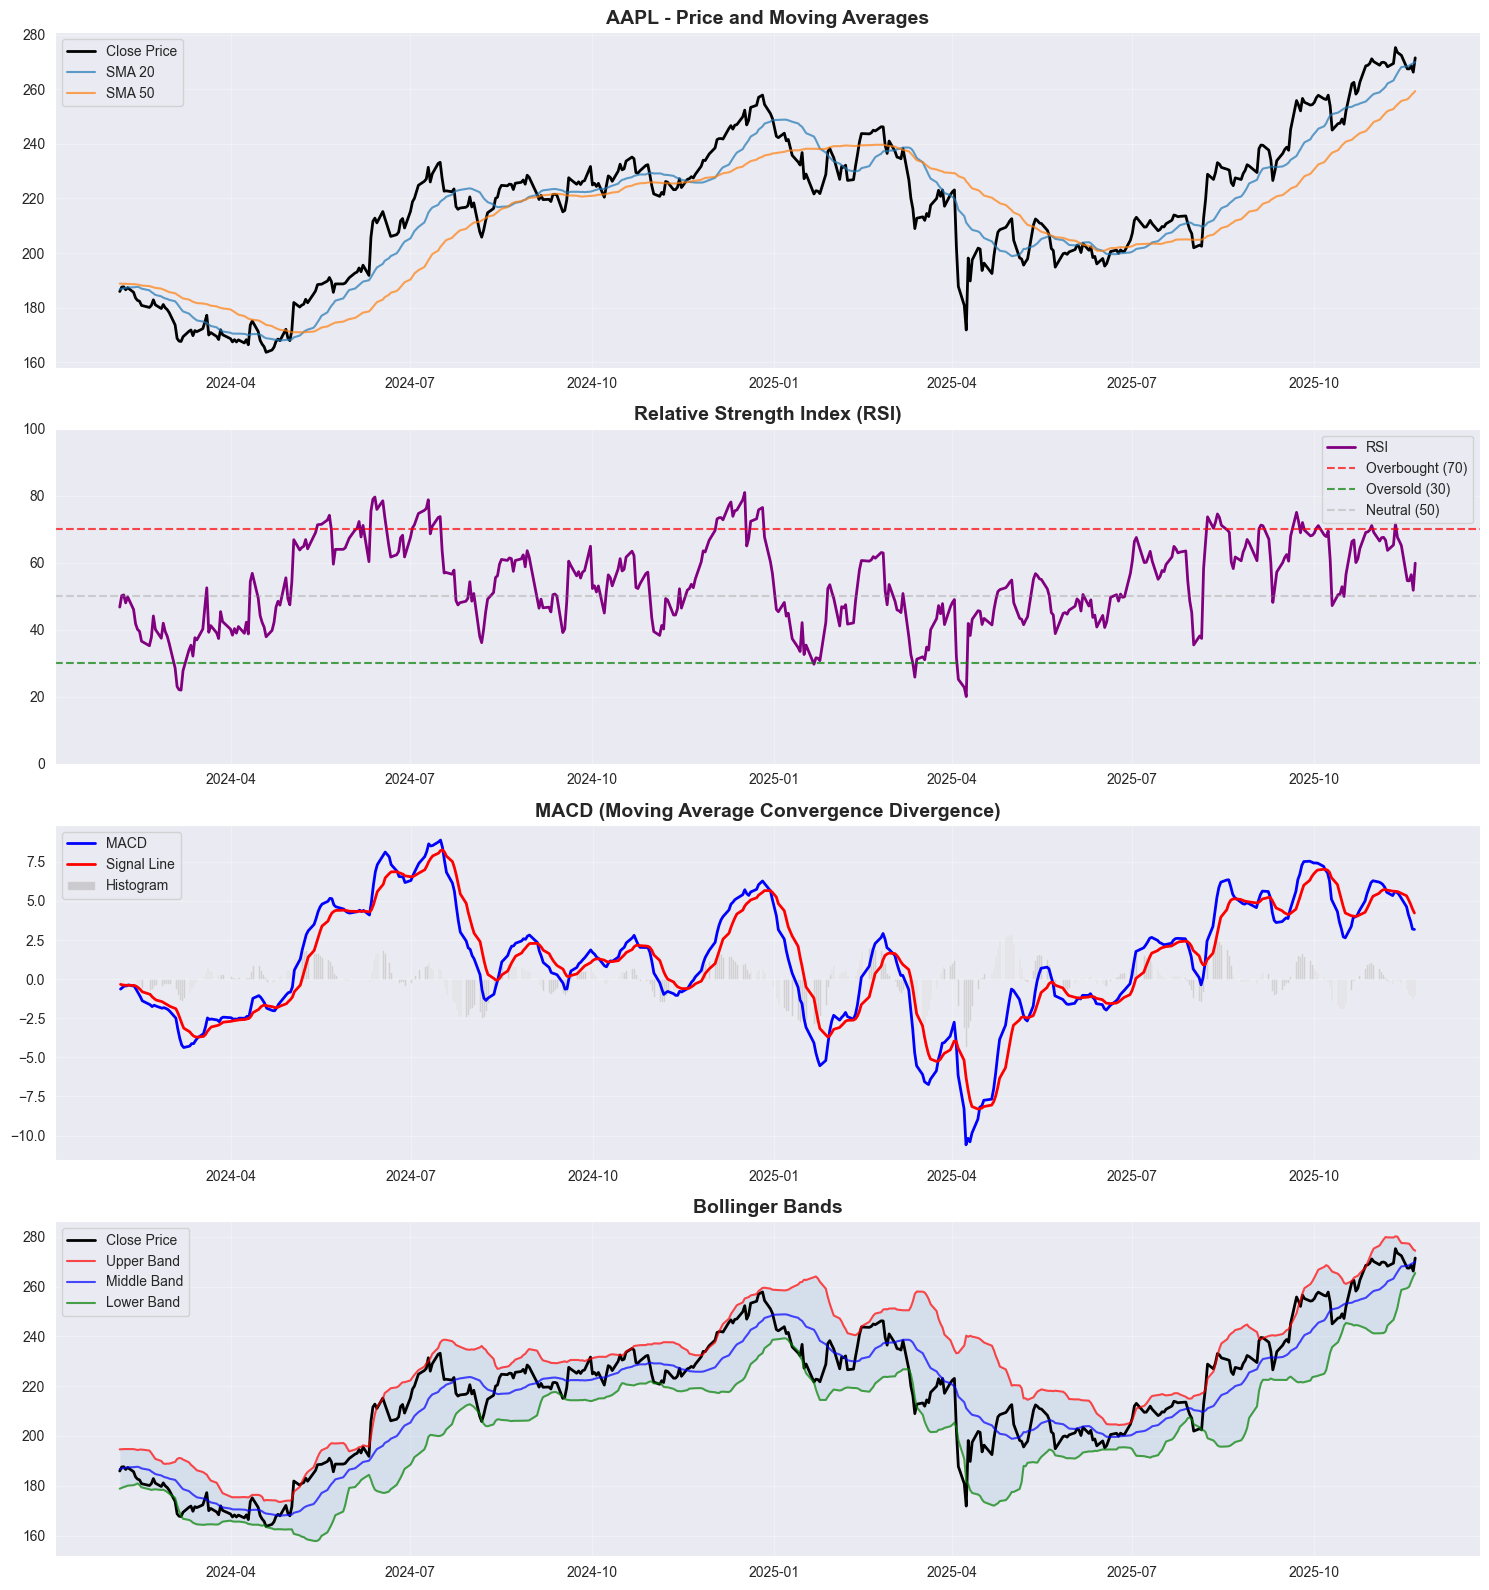

✅ Successfully plotted AAPL
📈 Generating technical analysis charts for GOOGL...


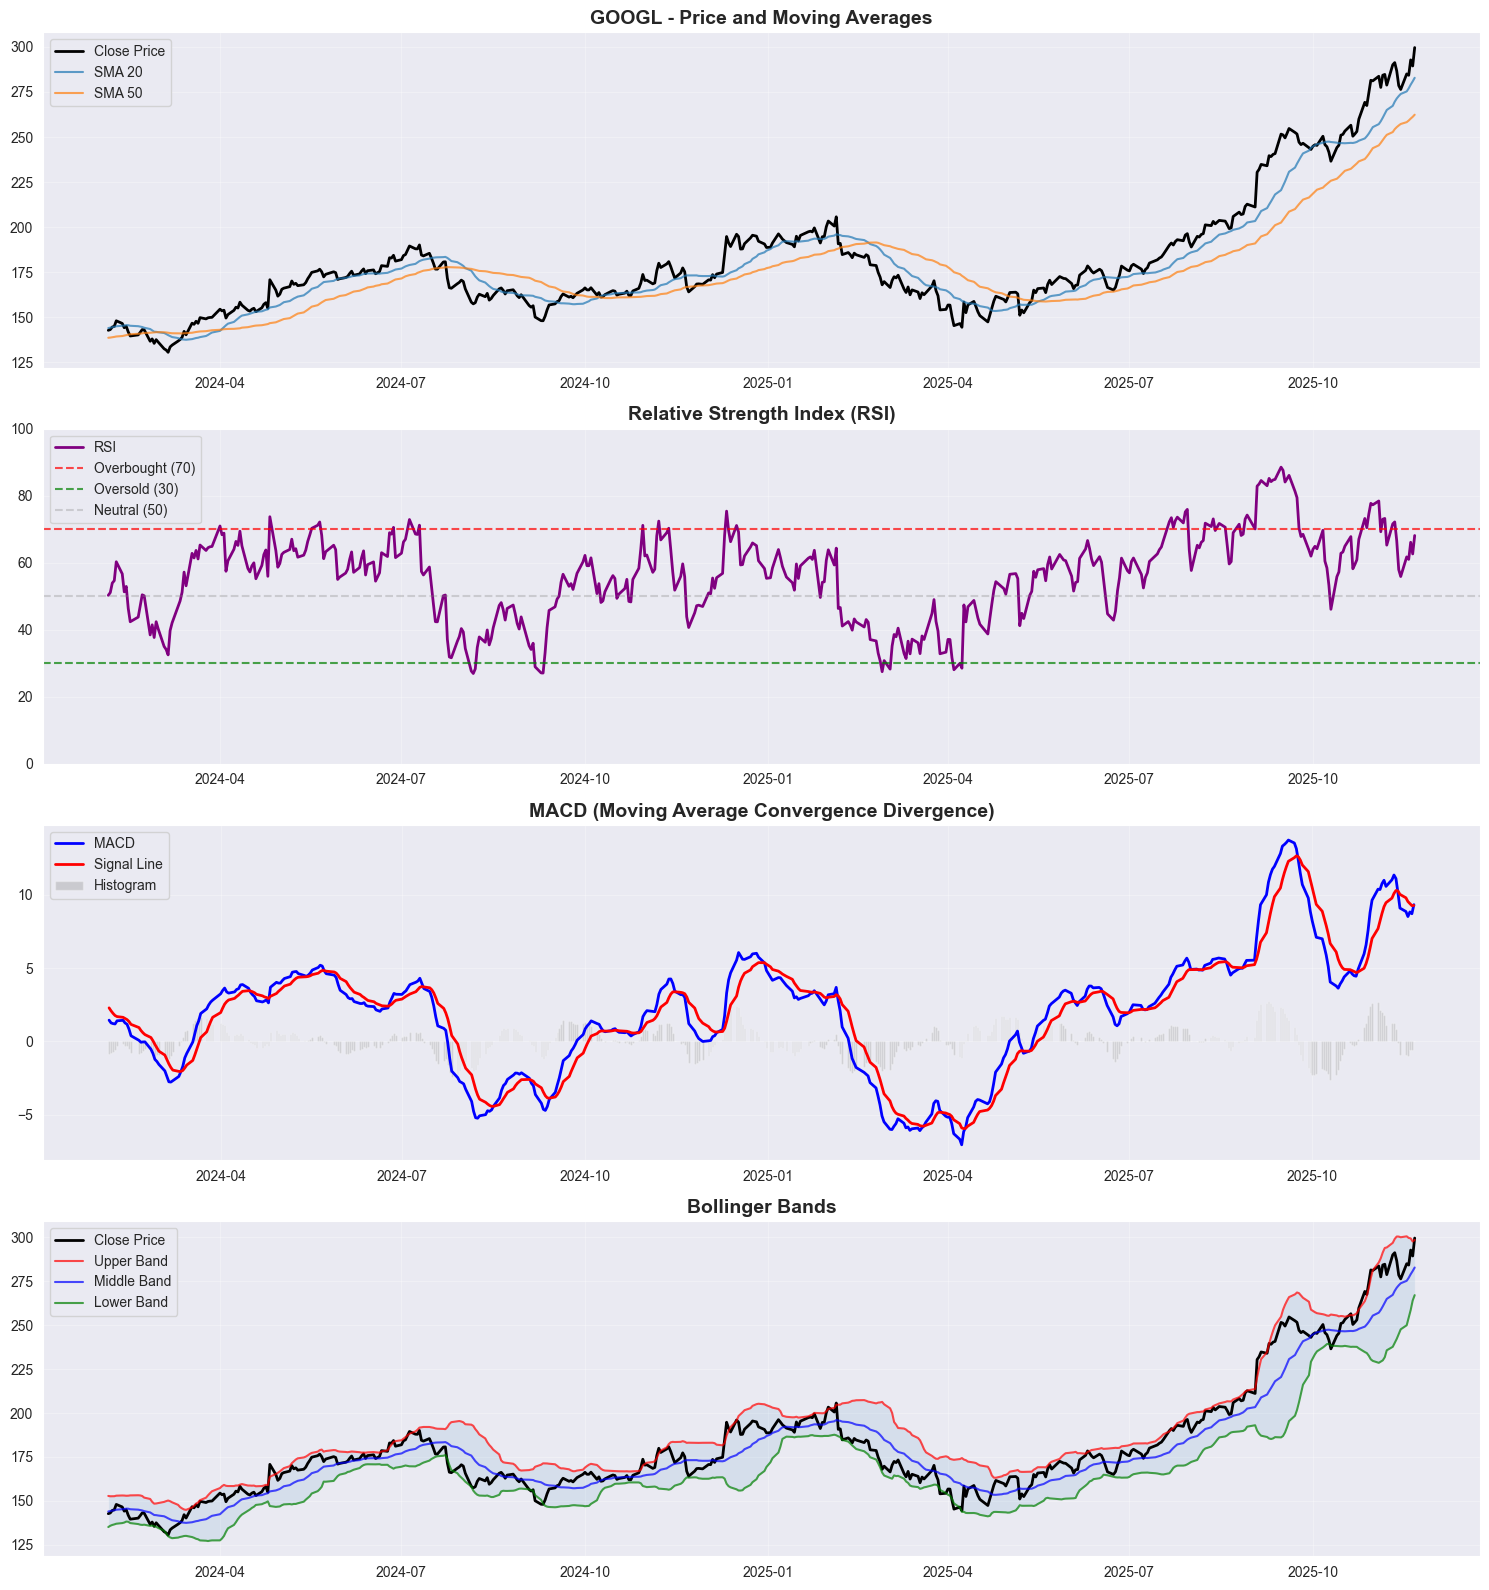

✅ Successfully plotted GOOGL


In [10]:
# Visualize technical indicators with error handling
def plot_technical_analysis(symbol, data):
    """Create comprehensive technical analysis plots with error handling"""
    try:
        # Check if required columns exist
        required_columns = ['Close', 'SMA_20', 'SMA_50', 'RSI', 'MACD', 'BB_Upper', 'BB_Middle', 'BB_Lower']
        missing_columns = [col for col in required_columns if col not in data.columns]

        if missing_columns:
            print(f"❌ Missing columns for {symbol}: {missing_columns}")
            return

        # Check if we have enough data
        if len(data) < 50:
            print(f"❌ Not enough data for {symbol}: only {len(data)} rows")
            return

        fig, axes = plt.subplots(4, 1, figsize=(15, 16))

        # Plot 1: Price and Moving Averages
        axes[0].plot(data.index, data['Close'], label='Close Price', linewidth=2, color='black')
        axes[0].plot(data.index, data['SMA_20'], label='SMA 20', alpha=0.7)
        axes[0].plot(data.index, data['SMA_50'], label='SMA 50', alpha=0.7)
        axes[0].set_title(f'{symbol} - Price and Moving Averages', fontsize=14, fontweight='bold')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        # Plot 2: RSI
        axes[1].plot(data.index, data['RSI'], label='RSI', color='purple', linewidth=2)
        axes[1].axhline(70, linestyle='--', alpha=0.7, color='red', label='Overbought (70)')
        axes[1].axhline(30, linestyle='--', alpha=0.7, color='green', label='Oversold (30)')
        axes[1].axhline(50, linestyle='--', alpha=0.3, color='gray', label='Neutral (50)')
        axes[1].set_title('Relative Strength Index (RSI)', fontsize=14, fontweight='bold')
        axes[1].set_ylim(0, 100)
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        # Plot 3: MACD
        axes[2].plot(data.index, data['MACD'], label='MACD', color='blue', linewidth=2)
        axes[2].plot(data.index, data['MACD_Signal'], label='Signal Line', color='red', linewidth=2)
        axes[2].bar(data.index, data['MACD_Histogram'], label='Histogram', alpha=0.3, color='gray')
        axes[2].set_title('MACD (Moving Average Convergence Divergence)', fontsize=14, fontweight='bold')
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)

        # Plot 4: Bollinger Bands
        axes[3].plot(data.index, data['Close'], label='Close Price', color='black', linewidth=2)
        axes[3].plot(data.index, data['BB_Upper'], label='Upper Band', alpha=0.7, color='red')
        axes[3].plot(data.index, data['BB_Middle'], label='Middle Band', alpha=0.7, color='blue')
        axes[3].plot(data.index, data['BB_Lower'], label='Lower Band', alpha=0.7, color='green')
        axes[3].fill_between(data.index, data['BB_Upper'], data['BB_Lower'], alpha=0.1)
        axes[3].set_title('Bollinger Bands', fontsize=14, fontweight='bold')
        axes[3].legend()
        axes[3].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()
        print(f"✅ Successfully plotted {symbol}")

    except Exception as e:
        print(f"❌ Error plotting {symbol}: {e}")

# Plot for first available stock
for symbol in list(all_stocks_data.keys())[:2]:  # Plot first 2 stocks
    print(f"📈 Generating technical analysis charts for {symbol}...")
    plot_technical_analysis(symbol, all_stocks_data[symbol])

📊 STOCK PERFORMANCE COMPARISON

📈 Performance Summary (Sorted by Total Return):


,Symbol,Current_Price,Total_Return_%,RSI,MACD,Price_vs_SMA20_%,Volume_Ratio
6,NVDA,178.88,267.41,41.48,-1.51,-7.29,1.0
1,GOOGL,299.66,117.87,68.10,9.32,5.93,1.0
7,JPM,298.02,103.22,40.55,-1.26,-3.22,1.0
5,META,594.25,75.09,26.37,-32.45,-6.94,1.0
4,TSLA,391.09,66.98,38.26,-10.14,-9.51,1.0
3,AMZN,220.69,50.43,40.65,-1.18,-6.58,1.0
0,AAPL,271.49,43.25,59.85,3.18,0.57,1.0
8,JNJ,203.90,42.84,79.82,4.03,5.89,1.0
9,V,327.98,31.18,40.82,-4.71,-2.18,1.0
2,MSFT,472.12,26.81,28.39,-8.69,-6.99,1.0


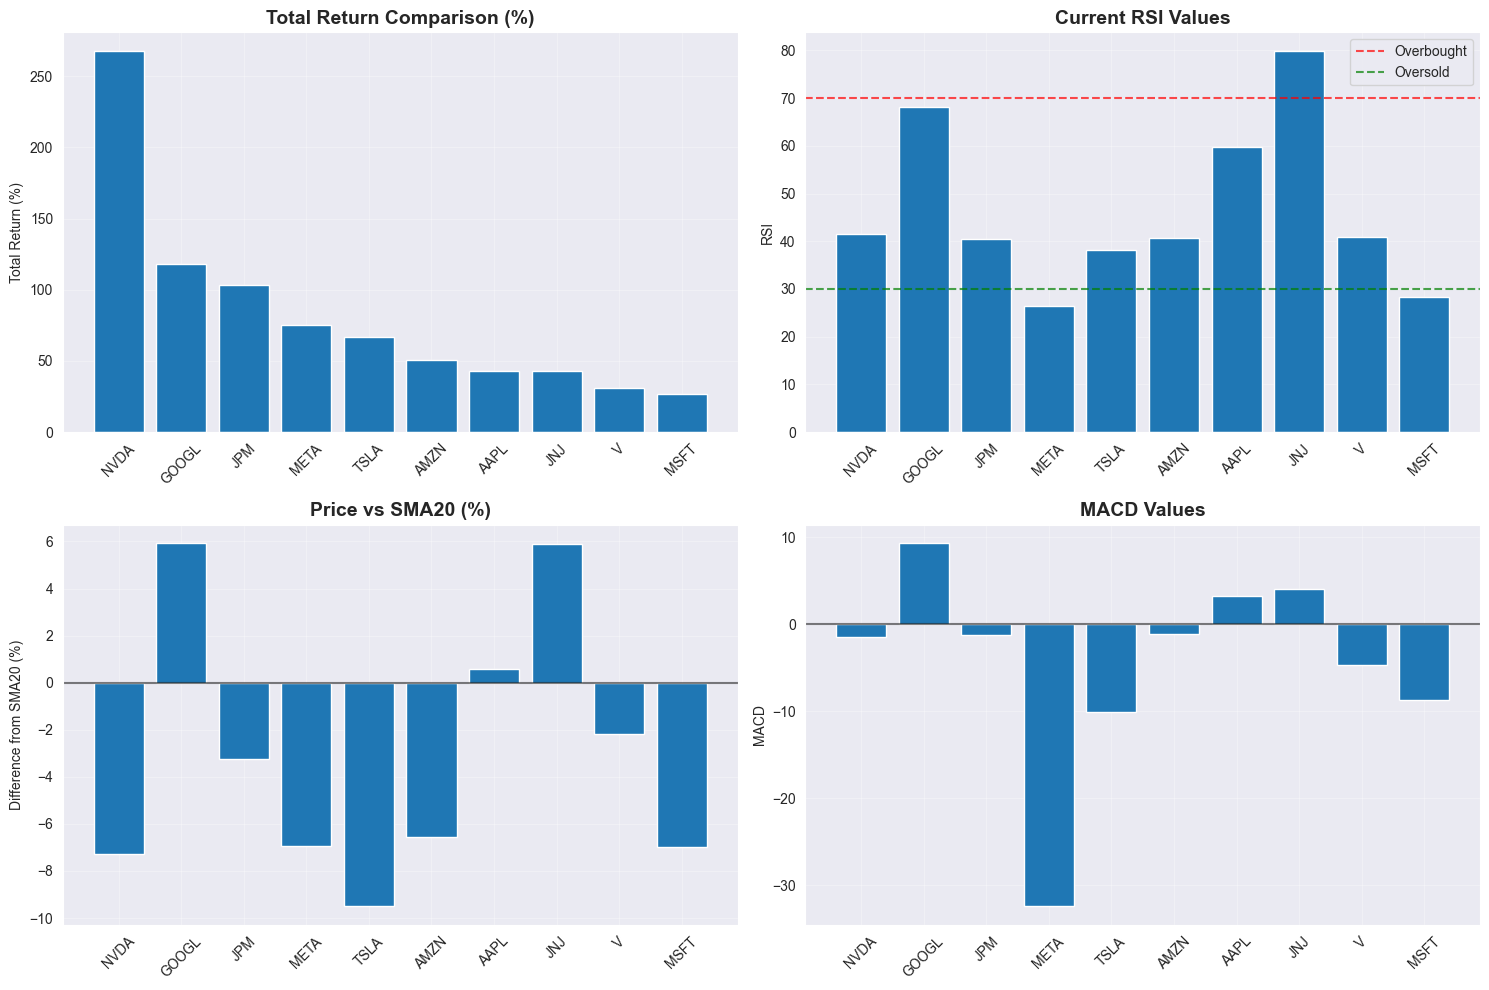

In [11]:
# Compare stock performances
print("📊 STOCK PERFORMANCE COMPARISON")

performance_data = []
for symbol, data in all_stocks_data.items():
    if len(data) > 0:
        latest_data = data.iloc[-1]
        performance_data.append({
            'Symbol': symbol,
            'Current_Price': latest_data['Close'],
            'Total_Return_%': (latest_data['Cumulative_Return'] - 1) * 100,
            'RSI': latest_data['RSI'],
            'MACD': latest_data['MACD'],
            'Price_vs_SMA20_%': (latest_data['Close'] / latest_data['SMA_20'] - 1) * 100,
            'Volume_Ratio': latest_data['Volume'] / latest_data['Volume'].mean()
        })

performance_df = pd.DataFrame(performance_data)
performance_df = performance_df.sort_values('Total_Return_%', ascending=False)

print("\n📈 Performance Summary (Sorted by Total Return):")
display(performance_df.round(2))

# Plot performance comparison
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.bar(performance_df['Symbol'], performance_df['Total_Return_%'])
plt.title('Total Return Comparison (%)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel('Total Return (%)')
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
plt.bar(performance_df['Symbol'], performance_df['RSI'])
plt.axhline(70, linestyle='--', color='red', alpha=0.7, label='Overbought')
plt.axhline(30, linestyle='--', color='green', alpha=0.7, label='Oversold')
plt.title('Current RSI Values', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel('RSI')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 3)
plt.bar(performance_df['Symbol'], performance_df['Price_vs_SMA20_%'])
plt.axhline(0, linestyle='-', color='black', alpha=0.5)
plt.title('Price vs SMA20 (%)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel('Difference from SMA20 (%)')
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 4)
plt.bar(performance_df['Symbol'], performance_df['MACD'])
plt.axhline(0, linestyle='-', color='black', alpha=0.5)
plt.title('MACD Values', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel('MACD')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
# Generate trading signals based on technical indicators
print("🔍 GENERATING TECHNICAL TRADING SIGNALS")

def generate_trading_signals(df):
    """Generate trading signals based on multiple technical indicators"""
    if len(df) == 0:
        return None

    latest = df.iloc[-1]

    signals = []

    # RSI Signal
    rsi = latest['RSI']
    if rsi > 70:
        rsi_signal = "SELL (Overbought)"
    elif rsi < 30:
        rsi_signal = "BUY (Oversold)"
    else:
        rsi_signal = "HOLD"

    # MACD Signal
    macd = latest['MACD']
    macd_signal_line = latest['MACD_Signal']
    if macd > macd_signal_line and latest['MACD_Histogram'] > 0:
        macd_signal = "BULLISH"
    elif macd < macd_signal_line and latest['MACD_Histogram'] < 0:
        macd_signal = "BEARISH"
    else:
        macd_signal = "NEUTRAL"

    # Moving Average Signal
    price = latest['Close']
    sma_20 = latest['SMA_20']
    sma_50 = latest['SMA_50']

    if price > sma_20 and sma_20 > sma_50:
        ma_signal = "STRONG BULLISH"
    elif price > sma_20:
        ma_signal = "BULLISH"
    elif price < sma_20 and sma_20 < sma_50:
        ma_signal = "STRONG BEARISH"
    else:
        ma_signal = "BEARISH"

    # Bollinger Bands Signal
    bb_upper = latest['BB_Upper']
    bb_lower = latest['BB_Lower']
    if price > bb_upper:
        bb_signal = "OVERBOUGHT"
    elif price < bb_lower:
        bb_signal = "OVERSOLD"
    else:
        bb_signal = "NEUTRAL"

    # Overall Signal (simple consensus)
    bullish_count = sum([
        1 if rsi_signal == "BUY (Oversold)" else 0,
        1 if macd_signal == "BULLISH" else 0,
        1 if "BULLISH" in ma_signal else 0,
        1 if bb_signal == "OVERSOLD" else 0
    ])

    bearish_count = sum([
        1 if rsi_signal == "SELL (Overbought)" else 0,
        1 if macd_signal == "BEARISH" else 0,
        1 if "BEARISH" in ma_signal else 0,
        1 if bb_signal == "OVERBOUGHT" else 0
    ])

    if bullish_count >= 3:
        overall_signal = "STRONG BUY"
    elif bullish_count >= 2:
        overall_signal = "BUY"
    elif bearish_count >= 3:
        overall_signal = "STRONG SELL"
    elif bearish_count >= 2:
        overall_signal = "SELL"
    else:
        overall_signal = "HOLD"

    return {
        'Symbol': latest['Symbol'],
        'Price': price,
        'Overall_Signal': overall_signal,
        'RSI': f"{rsi:.1f} ({rsi_signal})",
        'MACD': macd_signal,
        'MA_Signal': ma_signal,
        'BB_Signal': bb_signal,
        'Bullish_Indicators': bullish_count,
        'Bearish_Indicators': bearish_count
    }

# Generate signals for all stocks
trading_signals = []
for symbol, data in all_stocks_data.items():
    signals = generate_trading_signals(data)
    if signals:
        trading_signals.append(signals)

signals_df = pd.DataFrame(trading_signals)
signals_df = signals_df.sort_values('Overall_Signal')

print("\n🎯 TRADING SIGNALS SUMMARY:")
display(signals_df)

🔍 GENERATING TECHNICAL TRADING SIGNALS

🎯 TRADING SIGNALS SUMMARY:


,Symbol,Price,Overall_Signal,RSI,MACD,MA_Signal,BB_Signal,Bullish_Indicators,Bearish_Indicators
1,GOOGL,299.660004,BUY,68.1 (HOLD),BULLISH,STRONG BULLISH,OVERBOUGHT,2,1
8,JNJ,203.899994,BUY,79.8 (SELL (Overbought)),BULLISH,STRONG BULLISH,NEUTRAL,2,1
0,AAPL,271.489990,HOLD,59.9 (HOLD),BEARISH,STRONG BULLISH,NEUTRAL,1,1
2,MSFT,472.119995,SELL,28.4 (BUY (Oversold)),BEARISH,STRONG BEARISH,NEUTRAL,1,2
3,AMZN,220.690002,SELL,40.6 (HOLD),BEARISH,BEARISH,NEUTRAL,0,2
4,TSLA,391.089996,SELL,38.3 (HOLD),BEARISH,STRONG BEARISH,NEUTRAL,0,2
5,META,594.250000,SELL,26.4 (BUY (Oversold)),BEARISH,STRONG BEARISH,NEUTRAL,1,2
6,NVDA,178.880005,SELL,41.5 (HOLD),BEARISH,BEARISH,NEUTRAL,0,2
7,JPM,298.019989,SELL,40.5 (HOLD),BEARISH,BEARISH,NEUTRAL,0,2
9,V,327.980011,SELL,40.8 (HOLD),BEARISH,STRONG BEARISH,NEUTRAL,0,2
